## Load data
Importing the cleaned dataset and making sure it was loaded correctly by displaying first 5 rows. 

In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
from scipy.stats import kstest


books = pd.read_csv('data/books_clean.csv')
books.head()

,Unnamed: 0,Title,Price,Rating,Category,Availability
0,0,A Light in the ...,51.77,3,Poetry,In stock
1,1,Tipping the Velvet,53.74,1,Historical Fiction,In stock
2,2,Soumission,50.10,1,Fiction,In stock
3,3,Sharp Objects,47.82,4,Mystery,In stock
4,4,Sapiens: A Brief History ...,54.23,5,History,In stock


## Price analysis (1)
The range of prices is analyzed by its maximum, minimum, mean and median. 

While the range of prices is wide ( [10.0, 59.99] ), both mean and the median are approximately the same ( ~35.07, ~35.98), showing that the price distribution is approximately symmetric with a very slight negative skew.  

In [3]:

max_price = books['Price'].max()
min_price = books["Price"].min()
mean_price = books['Price'].mean()
median_price = books['Price'].median()

print('Max price:', max_price)
print('Min price:', min_price)
print('Mean:', mean_price)
print('Median:', median_price)

Max price: 59.99
Min price: 10.0
Mean: 35.07035
Median: 35.980000000000004


## Price analysis (2)
The histogram of the price range is created in order to approximate if the price distribution is close to any existing distribution. 



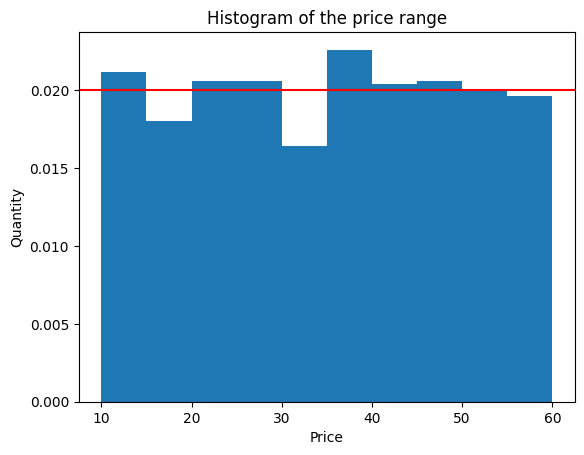

In [4]:
plt.hist(books['Price'], bins = 10, density = True)
uniform = 1/(books['Price'].max() - books['Price'].min())
plt.axhline(y = uniform, color = 'red')

plt.xlabel('Price')
plt.ylabel('Quantity')
plt.title('Histogram of the price range')
plt.show()



The histogram shows that price values have similar densities across the range. 

The histogram displays the density instead of actual quantity in order to compare the results with a theoretical uniform distribution, which seems to be a relatively close approximation of the price distribution.

Kolmogorov-Smirnov test is performed to test the hypothesis of the price distribution following a uniform distribution. 

In [ ]:
norm_price = (books['Price'] - min_price) / (max_price - min_price)
kstest(norm_price, 'uniform')

KstestResult(statistic=np.float64(0.022105021004200864), pvalue=np.float64(0.7042151671895571), statistic_location=np.float64(0.5251050210042009), statistic_sign=np.int8(-1))

The p-value is ~0.704. Considering that the significance level = 0.05 is used, we do not reject the null hypothesis (0.704 > 0.05).
As a result, the books prices can be approximated as uniform, as there is not enough evidence to conclude otherwise. 

The final conclusion:
Prices are spread relatively evenly, so there is no strong concentration of books in either high-cost or more budget-friendly categories.

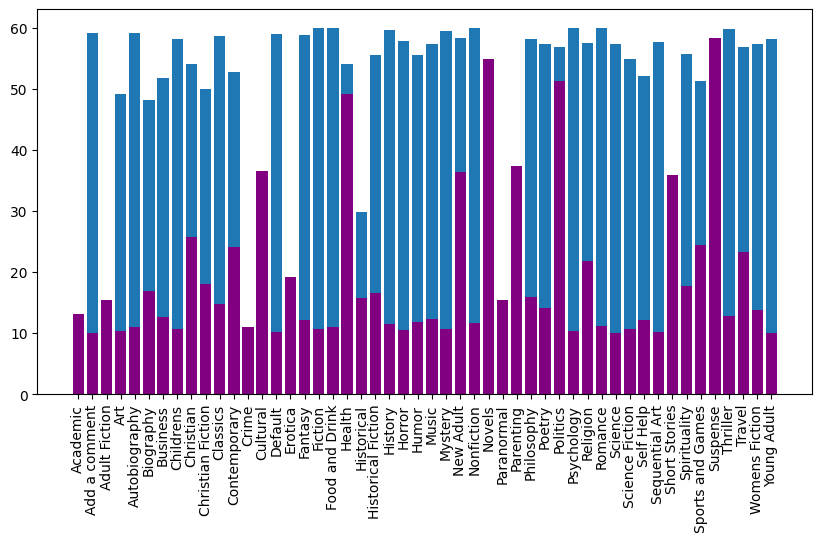

: 

In [ ]:
category_group = books.groupby("Category")["Price"]

min = category_group.min()
max = category_group.max()

plt.figure(figsize = (10, 5))
plt.bar(max.index, max.values)
plt.bar(min.index, min.values, color = "purple")
plt.xticks(rotation = 90)
plt.show()

